# **Vodafone Music Challenge**


## Обґрунтування вибору задачі

У межах проєкту було запропоновано два варіанти датасетів:

- **Vodafone Age** — задача багатокласової класифікації (multiclass classification)
- **Vodafone Music** — задача бінарної класифікації (binary classification)

Для реалізації проєкту було обрано **Vodafone Music (binary classification)**.

### Причини вибору
- Задача має чітке бізнес-застосування (таргетований маркетинг).
- Бінарна класифікація дозволяє глибше сфокусуватися на якості моделі.
- Метрика ROC-AUC добре підходить для задач з незбалансованими класами.
- Задача безпосередньо пов’язана з прогнозуванням поведінки користувачів.

## Що саме прогнозуємо?

Модель прогнозує **ймовірність того, що абонент встановить та оплатить перший місяць користування додатком Vodafone Music протягом місяця після дати скорингу**.

### Таргет:
- **1** — абонент встановив та оплатив Vodafone Music.
- **0** — абонент не встановив додаток.

## Як модель може бути використана бізнесом?

Модель використовується для **таргетованого промотування сервісу Vodafone Music**.

### Практичне застосування:

- Формування списку абонентів із високою ймовірністю встановлення.
- Оптимізація маркетингового бюджету.
- Персоналізовані SMS/Push-розсилки.
- A/B тестування рекламних кампаній.
- Підвищення конверсії та зменшення вартості залучення клієнта (CAC).

### Бізнес-ефект:

- Збільшення кількості підписок.
- Зростання ARPU (Average Revenue Per User).
- Підвищення ефективності рекламних кампаній.
- Зменшення витрат на нерелевантні контакти.

## Найбільш критичні помилки моделі

У задачі бінарної класифікації можливі два типи помилок:

## False Positive (FP)
Модель прогнозує, що абонент встановить додаток, але насправді він не встановлює його.

**Наслідки:**
- Зайві витрати на маркетинг.
- Потенційне роздратування клієнта.
- Зниження ефективності кампанії.

## False Negative (FN)
Модель прогнозує, що абонент не встановить додаток, але він міг би це зробити.

**Наслідки:**
- Втрата потенційного доходу.
- Недоотриманий прибуток.
- Зменшення кількості нових підписок.

### Яка помилка більш критична?

У більшості маркетингових задач **більш критичною є False Negative (FN)**, оскільки:

- Це пряма втрата потенційного доходу.
- Бізнес втрачає можливість залучити клієнта.

Проте у випадку дуже дорогих маркетингових кампаній FP також можуть бути суттєвими.

Баланс між FP та FN визначається бізнес-стратегією та бюджетом.

## Метрика оцінювання

Будемо користатися метрикою **ROC-AUC**.

ROC-AUC дозволяє:
- Оцінювати якість ранжування.
- Порівнювати моделі незалежно від порогу класифікації.
- Працювати з незбалансованими класами.

# **Initial Data Exploration**

### Завантаження та перегляд даних

In [ ]:
import pandas as pd

df = pd.read_csv('sample_data/train_music.csv')
df.head()

,id,target,device_type,manufacturer_category,os_category,sim_count,tp_flag,lt,block_flag,days_exp,...,service_5_count_m3,service_6_count_m3,service_7_cost_m3,service_7_flag_m3,service_8_count_m3,income_brnd_cont_m3,data_type_1_m3,data_type_2_m3,data_type_3_m3,service_9_flag_m3
0,48104912810,0,7,1514,3,1.0,0,0.496508,0,299.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,13762.315646,1292.468784,NaN
1,4851497268,0,4,896,28,1.0,0,0.881540,0,189.0,...,11.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.000053,NaN
2,4877823097,0,7,592,3,2.0,0,0.811192,0,347.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.000977,NaN
3,4830183791,0,7,1756,3,2.0,0,0.928449,1,343.0,...,66.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.006680,NaN
4,48103940036,0,4,1057,28,1.0,0,0.578654,0,355.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.002487,1.0


### Пошук бінарних колонок (0/1)

In [ ]:
binary_cols = [col for col in df.columns if df[col].dropna().isin([0, 1]).all()]
print("Binary columns:", binary_cols)

Binary columns: ['target', 'tp_flag', 'block_flag', 'service_1_flag', 'service_2_flag', 'service_3_flag', 'is_obl_center', 'is_my_vf', 'count_sms_source_2', 'rr_act_type_7', 'rr_gift_type_1', 'service_P_flag_m1', 'voice_omo_in_cost_m1', 'voice_pstn_in_cost_m1', 'voice_onnet_cc_dur_m1', 'voice_pstn_out_count_m1', 'voice_onnet_cc_count_m1', 'voice_omo_cc_count_m1', 'sms_roam_in_count_m1', 'service_8_count_m1', 'service_9_flag_m1', 'service_P_flag_m2', 'sms_roam_cost_m2', 'voice_omo_in_cost_m2', 'voice_pstn_in_cost_m2', 'voice_onnet_cc_dur_m2', 'voice_pstn_out_count_m2', 'voice_onnet_cc_count_m2', 'sms_roam_in_count_m2', 'service_8_count_m2', 'service_9_flag_m2', 'service_P_flag_m3', 'sms_roam_cost_m3', 'voice_omo_in_cost_m3', 'voice_pstn_in_cost_m3', 'voice_onnet_cc_dur_m3', 'voice_onnet_cc_count_m3', 'voice_omo_cc_count_m3', 'sms_roam_in_count_m3', 'service_8_count_m3', 'service_9_flag_m3']


### Визначення списку потрібних колонок (headers)

Cтворюємо список existing_headers, який містить назви колонок, з якими плануємо працювати далі.

In [ ]:
existing_headers = [

    "id", "target",
    "device_type", "manufacturer_category", "os_category", "sim_count",

    "tp_flag", "LT", "block_flag", "days_exp", "service_1_flag","service_1_count",
    "service_2_flag", "service_3_flag", "is_obl_center", "is_my_vf",

    "balance_sum", "paym_last_days", "inact_days_count",

    "count_sms_source_1", "count_sms_source_2", "count_sms_source_3",
    "count_sms_source_4", "count_sms_source_5","count_sms_source_6",
    "count_sms_source_7", "count_sms_source_8", "count_sms_source_9",
    "count_sms_source_10", "count_sms_source_11", "count_sms_source_12",
    "count_sms_source_13", "count_sms_source_14", "count_sms_source_15",
    "count_sms_source_16",

    "count_url_category_1", "count_url_category_2", "count_url_category_3",
    "count_url_category_4", "count_url_category_6", "count_url_category_7",
    "count_url_category_8", "count_url_category_9", "count_url_category_10",
    "count_url_category_11", "count_url_category_12", "count_url_category_13",
    "count_url_category_15", "vol_app_1", "vol_app_2", "vol_app_3",
    "vol_app_4", "vol_app_5", "vol_app_6", "vol_app_7", "vol_app_8",
    "vol_app_9", "vol_app_10", "vol_app_11", "vol_app_12", "vol_app_13",
    "vol_app_14", "vol_app_15", "vol_app_16",
    "count_app_1", "count_app_2", "count_app_3",
    "count_app_4", "count_app_5", "count_app_6",
    "count_app_7", "count_app_8", "count_app_9",
    "count_app_10", "count_app_11", "count_app_12",
    "count_app_13", "count_app_14", "count_app_15", "count_app_16",

    "rr_act_type_1", "rr_act_type_2", "rr_act_type_3",
    "rr_act_type_4", "rr_act_type_5", "rr_act_type_6",
    "rr_act_type_7", "rr_act_type_8", "rr_gift_type_1",
    "rr_gift_type_2", "rr_gift_type_3", "rr_gift_type_4",
    "count_act_type_1", "count_act_type_2", "count_act_type_3",
    "count_act_type_4", "count_act_type_5", "count_act_type_6",
    "count_act_type_7", "count_act_type_8", "count_gift_type_1",
    "count_gift_type_2", "count_gift_type_3","count_gift_type_4",


    "service_P_flag_m1",
    "block_all_dur_m1", "block_count_m1",
    "all_cost_m1", "all_home_clc_m1", "all_roam_cost_m1", "sms_cost_m1", "sms_roam_cost_m1",
    "content_cost_m1", "abon_cost_m1", "abon_part_m1", "act_days_count_m1", "com_num_cost_m1",
    "conn_com_cost_m1",
    "paym_el_count_m1", "paym_el_sum_m1", "paym_sum_m1", "pay_in_P2P_cost_m1",
    "pay_out_P2P_cost_m1", "paym_count_m1",
    "voice_onnet_out_cost_m1","voice_onnet_out_day_work_cost_m1",
    "voice_onnet_out_day_rest_cost_m1",
    "voice_onnet_out_night_work_cost_m1",
    "voice_onnet_out_night_rest_cost_m1",
    "voice_omo_out_day_work_cost_m1","voice_omo_out_day_rest_cost_m1",
    "voice_omo_out_night_work_cost_m1","voice_omo_out_night_rest_cost_m1",
    "voice_omo_out_cost_m1","voice_pstn_out_cost_m1",
    "voice_roam_out_cost_m1","voice_omo_in_cost_m1",
    "voice_pstn_in_cost_m1","voice_roam_in_cost_m1",
    "voice_all_out_dur_m1","voice_all_in_dur_m1",
    "voice_onnet_out_dur_m1","voice_onnet_in_dur_m1",
    "voice_onnet_out_day_work_dur_m1","voice_onnet_out_day_rest_dur_m1","voice_onnet_out_night_work_dur_m1","voice_onnet_out_night_rest_dur_m1",
    "voice_onnet_in_day_work_dur_m1","voice_onnet_in_day_rest_dur_m1","voice_onnet_in_night_work_dur_m1","voice_onnet_in_night_rest_dur_m1",
    "voice_omo_out_dur_m1","voice_omo_in_dur_m1","voice_omo_out_day_work_dur_m1","voice_omo_out_day_rest_dur_m1","voice_omo_out_night_work_dur_m1",
    "voice_omo_out_night_rest_dur_m1","voice_omo_in_day_work_dur_m1","voice_omo_in_day_rest_dur_m1","voice_omo_in_night_work_dur_m1",
    "voice_omo_in_night_rest_dur_m1","voice_roam_out_dur_m1","voice_roam_in_dur_m1","voice_onnet_cc_dur_m1","voice_omo_cc_dur_m1",
    "voice_pstn_out_dur_m1","voice_pstn_in_dur_m1","all_count_m1","voice_all_out_count_m1","voice_all_in_count_m1","voice_onnet_out_count_m1",
    "voice_onnet_in_count_m1","voice_onnet_out_day_work_count_m1","voice_onnet_out_day_rest_count_m1","voice_onnet_out_night_work_count_m1",
    "voice_onnet_out_night_rest_count_m1","voice_onnet_in_day_work_count_m1","voice_onnet_in_day_rest_count_m1","voice_onnet_in_night_work_count_m1",
    "voice_onnet_in_night_rest_count_m1","voice_omo_out_count_m1","voice_omo_in_count_m1","voice_omo_out_day_work_count_m1","voice_omo_out_day_rest_count_m1",
    "voice_omo_out_night_work_count_m1","voice_omo_out_night_rest_count_m1","voice_omo_in_day_work_count_m1","voice_omo_in_day_rest_count_m1",
    "voice_omo_in_night_work_count_m1","voice_omo_in_night_rest_count_m1","voice_global_out_count_m1","voice_global_in_count_m1","voice_global_day_work_count_m1",
    "voice_global_day_rest_count_m1","voice_global_night_work_count_m1","voice_global_night_rest_count_m1","voice_roam_out_count_m1","voice_roam_in_count_m1",
    "voice_pstn_out_count_m1","voice_pstn_in_count_m1","voice_onnet_cc_count_m1","voice_omo_cc_count_m1","short_in_calls_part_m1","short_out_calls_part_m1",
    "voice_out_uniq_count_m1","voice_in_uniq_count_m1","sms_out_count_m1","sms_in_count_m1","sms_onnet_out_pack_count_m1","sms_omo_out_pack_count_m1",
    "sms_roam_out_count_m1","sms_roam_in_count_m1","content_count_m1","service_5_count_m1","service_6_count_m1","service_7_cost_m1","service_7_flag_m1",
    "service_8_count_m1","income_brnd_cont_m1","data_type_1_m1","data_type_2_m1","data_type_3_m1","service_9_flag_m1",


    "service_P_flag_m2","block_all_dur_m2","block_count_m2","all_cost_m2","all_home_clc_m2","all_roam_cost_m2","sms_cost_m2","sms_roam_cost_m2",
    "content_cost_m2","abon_cost_m2","abon_part_m2","act_days_count_m2","com_num_cost_m2","conn_com_cost_m2","paym_el_count_m2","paym_el_sum_m2",
    "paym_sum_m2","pay_in_P2P_cost_m2","pay_out_P2P_cost_m2","paym_count_m2","voice_onnet_out_cost_m2","voice_onnet_out_day_work_cost_m2",
    "voice_onnet_out_day_rest_cost_m2","voice_onnet_out_night_work_cost_m2","voice_onnet_out_night_rest_cost_m2","voice_omo_out_day_work_cost_m2",
    "voice_omo_out_day_rest_cost_m2","voice_omo_out_night_work_cost_m2","voice_omo_out_night_rest_cost_m2","voice_omo_out_cost_m2","voice_pstn_out_cost_m2",
    "voice_roam_out_cost_m2","voice_omo_in_cost_m2","voice_pstn_in_cost_m2","voice_roam_in_cost_m2","voice_all_out_dur_m2","voice_all_in_dur_m2",
    "voice_onnet_out_dur_m2","voice_onnet_in_dur_m2","voice_onnet_out_day_work_dur_m2","voice_onnet_out_day_rest_dur_m2","voice_onnet_out_night_work_dur_m2",
    "voice_onnet_out_night_rest_dur_m2","voice_onnet_in_day_work_dur_m2","voice_onnet_in_day_rest_dur_m2","voice_onnet_in_night_work_dur_m2",
    "voice_onnet_in_night_rest_dur_m2","voice_omo_out_dur_m2","voice_omo_in_dur_m2","voice_omo_out_day_work_dur_m2","voice_omo_out_day_rest_dur_m2",
    "voice_omo_out_night_work_dur_m2","voice_omo_out_night_rest_dur_m2","voice_omo_in_day_work_dur_m2","voice_omo_in_day_rest_dur_m2","voice_omo_in_night_work_dur_m2",
    "voice_omo_in_night_rest_dur_m2","voice_roam_out_dur_m2","voice_roam_in_dur_m2","voice_onnet_cc_dur_m2","voice_omo_cc_dur_m2","voice_pstn_out_dur_m2",
    "voice_pstn_in_dur_m2","all_count_m2","voice_all_out_count_m2","voice_all_in_count_m2","voice_onnet_out_count_m2","voice_onnet_in_count_m2",
    "voice_onnet_out_day_work_count_m2","voice_onnet_out_day_rest_count_m2","voice_onnet_out_night_work_count_m2","voice_onnet_out_night_rest_count_m2",
    "voice_onnet_in_day_work_count_m2","voice_onnet_in_day_rest_count_m2","voice_onnet_in_night_work_count_m2","voice_onnet_in_night_rest_count_m2",
    "voice_omo_out_count_m2","voice_omo_in_count_m2","voice_omo_out_day_work_count_m2","voice_omo_out_day_rest_count_m2","voice_omo_out_night_work_count_m2",
    "voice_omo_out_night_rest_count_m2","voice_omo_in_day_work_count_m2","voice_omo_in_day_rest_count_m2","voice_omo_in_night_work_count_m2",
    "voice_omo_in_night_rest_count_m2","voice_global_out_count_m2","voice_global_in_count_m2","voice_global_day_work_count_m2","voice_global_day_rest_count_m2",
    "voice_global_night_work_count_m2","voice_global_night_rest_count_m2","voice_roam_out_count_m2","voice_roam_in_count_m2","voice_pstn_out_count_m2",
    "voice_pstn_in_count_m2","voice_onnet_cc_count_m2","voice_omo_cc_count_m2","short_in_calls_part_m2","short_out_calls_part_m2","voice_out_uniq_count_m2",
    "voice_in_uniq_count_m2","sms_out_count_m2","sms_in_count_m2","sms_onnet_out_pack_count_m2","sms_omo_out_pack_count_m2","sms_roam_out_count_m2",
    "sms_roam_in_count_m2","content_count_m2","service_5_count_m2","service_6_count_m2","service_7_cost_m2","service_7_flag_m2","service_8_count_m2",


    "income_brnd_cont_m2","data_type_1_m2","data_type_2_m2","data_type_3_m2","service_9_flag_m2","service_P_flag_m3","block_all_dur_m3","block_count_m3",
    "all_cost_m3","all_home_clc_m3","all_roam_cost_m3","sms_cost_m3","sms_roam_cost_m3","content_cost_m3","abon_cost_m3","abon_part_m3","act_days_count_m3",
    "com_num_cost_m3","conn_com_cost_m3","paym_el_count_m3","paym_el_sum_m3","paym_sum_m3","pay_in_P2P_cost_m3","pay_out_P2P_cost_m3","paym_count_m3",
    "voice_onnet_out_cost_m3","voice_onnet_out_day_work_cost_m3","voice_onnet_out_day_rest_cost_m3","voice_onnet_out_night_work_cost_m3","voice_onnet_out_night_rest_cost_m3",
    "voice_omo_out_day_work_cost_m3","voice_omo_out_day_rest_cost_m3","voice_omo_out_night_work_cost_m3","voice_omo_out_night_rest_cost_m3","voice_omo_out_cost_m3",
    "voice_pstn_out_cost_m3","voice_roam_out_cost_m3","voice_omo_in_cost_m3","voice_pstn_in_cost_m3","voice_roam_in_cost_m3","voice_all_out_dur_m3","voice_all_in_dur_m3",
    "voice_onnet_out_dur_m3","voice_onnet_in_dur_m3","voice_onnet_out_day_work_dur_m3","voice_onnet_out_day_rest_dur_m3","voice_onnet_out_night_work_dur_m3",
    "voice_onnet_out_night_rest_dur_m3","voice_onnet_in_day_work_dur_m3","voice_onnet_in_day_rest_dur_m3","voice_onnet_in_night_work_dur_m3","voice_onnet_in_night_rest_dur_m3",
    "voice_omo_out_dur_m3","voice_omo_in_dur_m3","voice_omo_out_day_work_dur_m3","voice_omo_out_day_rest_dur_m3","voice_omo_out_night_work_dur_m3","voice_omo_out_night_rest_dur_m3",
    "voice_omo_in_day_work_dur_m3","voice_omo_in_day_rest_dur_m3","voice_omo_in_night_work_dur_m3","voice_omo_in_night_rest_dur_m3","voice_roam_out_dur_m3","voice_roam_in_dur_m3",
    "voice_onnet_cc_dur_m3","voice_omo_cc_dur_m3","voice_pstn_out_dur_m3","voice_pstn_in_dur_m3","all_count_m3","voice_all_out_count_m3","voice_all_in_count_m3",
    "voice_onnet_out_count_m3","voice_onnet_in_count_m3","voice_onnet_out_day_work_count_m3","voice_onnet_out_day_rest_count_m3","voice_onnet_out_night_work_count_m3",
    "voice_onnet_out_night_rest_count_m3","voice_onnet_in_day_work_count_m3","voice_onnet_in_day_rest_count_m3","voice_onnet_in_night_work_count_m3","voice_onnet_in_night_rest_count_m3",
    "voice_omo_out_count_m3","voice_omo_in_count_m3","voice_omo_out_day_work_count_m3","voice_omo_out_day_rest_count_m3","voice_omo_out_night_work_count_m3",
    "voice_omo_out_night_rest_count_m3","voice_omo_in_day_work_count_m3","voice_omo_in_day_rest_count_m3","voice_omo_in_night_work_count_m3","voice_omo_in_night_rest_count_m3",
    "voice_global_out_count_m3","voice_global_in_count_m3","voice_global_day_work_count_m3","voice_global_day_rest_count_m3","voice_global_night_work_count_m3",
    "voice_global_night_rest_count_m3","voice_roam_out_count_m3","voice_roam_in_count_m3","voice_pstn_out_count_m3","voice_pstn_in_count_m3","voice_onnet_cc_count_m3",
    "voice_omo_cc_count_m3","short_in_calls_part_m3","short_out_calls_part_m3","voice_out_uniq_count_m3","voice_in_uniq_count_m3","sms_out_count_m3","sms_in_count_m3",
    "sms_onnet_out_pack_count_m3","sms_omo_out_pack_count_m3","sms_roam_out_count_m3","sms_roam_in_count_m3","content_count_m3","service_5_count_m3","service_6_count_m3",
    "service_7_cost_m3","service_7_flag_m3","service_8_count_m3","income_brnd_cont_m3","data_type_1_m3","data_type_2_m3","data_type_3_m3","service_9_flag_m3"
]

print(len(existing_headers))

461


#### CSV → DataFrame з власними колонками

In [ ]:
# Читаем файл построчно
rows = []
with open('sample_data/train_music.csv', 'r', encoding='utf-8') as f:
    next(f)  # пропускаем первую строку (заголовок)
    for line in f:
        # Разделяем по запятой
        row = line.strip().split(',')
        rows.append(row)

# Определяем нужное количество колонок
num_columns = 461

# Дополняем строки, которые короче
rows_fixed = [r + [None]*(num_columns-len(r)) if len(r) < num_columns else r[:num_columns] for r in rows]

# Создаем DataFrame
df = pd.DataFrame(rows_fixed)

# Назначаем свои названия колонок
df.columns = existing_headers

# Проверяем
print(df.shape)
print(df.head())

(1495, 461)
            id target device_type manufacturer_category os_category sim_count  \
0  48104912810      0           7                  1514           3       1.0   
1   4851497268      0           4                   896          28       1.0   
2   4877823097      0           7                   592           3       2.0   
3   4830183791      0           7                  1756           3       2.0   
4  48103940036      0           4                  1057          28       1.0   

  tp_flag                  LT block_flag days_exp  ... service_5_count_m3  \
0       0   0.496507857848896          0    299.0  ...                0.0   
1       0    0.88154023585077          0    189.0  ...               11.0   
2       0  0.8111923342607823          0    347.0  ...                0.0   
3       0  0.9284494273364352          1    343.0  ...               66.0   
4       0  0.5786536734570925          0    355.0  ...                0.0   

  service_6_count_m3 service_7_cost_m3

### Інформація про DataFrame: кількість рядків, стовпців, типи даних та пропуски

DataFrame:

*   Має 18002 рядки (entries 0–18001)
*   Має 461 стовпець (від id до service_9_flag_m3)
*   Усі колонки мають тип object (тобто рядки/текст, навіть якщо там числа)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Columns: 461 entries, id to service_9_flag_m3
dtypes: object(461)
memory usage: 5.3+ MB


При завантаженні через open() і split(',') всі значення зчиталися як текст. Так як потрібні числові типи (int / float) для подальшого аналізу, їх потрібно конвертувати вручну.

Автоматично конвертуємо всі колонки, які можуть бути числами, у float або int, залишаючи текстові колонки без змін. Використовуємо pd.to_numeric з errors='coerce', щоб пропуски ставились там, де не вдається конвертувати.

In [ ]:
# Перевіримо всі колонки
for col in df.columns:
    # Пробуємо перетворити в числовий тип
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Після цього числові колонки будуть float, текстові залишаться NaN там, де не число
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Columns: 461 entries, id to service_9_flag_m3
dtypes: float64(452), int64(9)
memory usage: 5.3 MB
None


Згідно з виводом df.info(), DataFrame зараз виглядає так:

*   13996 рядків (entries 0–13995)
*   461 колонка (від id до service_9_flag_m3)
*   452 колонки мають тип float64
*   9 колонок мають тип int64

Таким чином, конвертація пройшла успішно: більшість числових колонок стала float, декілька цілих залишились як int. Текстових колонок більше немає — це означає, що майже всі дані тепер числові і готові для аналізу та моделей машинного навчання.

### Статистичний огляд колонок

In [ ]:
df.describe()

,id,target,device_type,manufacturer_category,os_category,sim_count,tp_flag,LT,block_flag,days_exp,...,service_5_count_m3,service_6_count_m3,service_7_cost_m3,service_7_flag_m3,service_8_count_m3,income_brnd_cont_m3,data_type_1_m3,data_type_2_m3,data_type_3_m3,service_9_flag_m3
count,1.495000e+03,1495.000000,1495.000000,1495.000000,1495.000000,1481.000000,1495.000000,1495.000000,1495.00000,1495.000000,...,1494.000000,1494.000000,1411.000000,1411.000000,1411.0,192.000000,188.000000,938.000000,1077.000000,89.0
mean,1.194841e+10,0.072241,6.552508,895.329097,7.414716,1.628629,0.082274,0.800333,0.02408,317.314381,...,24.161981,0.048862,0.295386,0.054571,0.0,16.834509,1947.287881,2469.617392,327.897013,1.0
std,1.630995e+10,0.258973,1.171855,485.685382,9.363937,0.483335,0.274874,0.151938,0.15335,78.585147,...,48.952557,0.273198,2.139666,0.343943,0.0,22.533887,3536.363201,5742.210706,1116.594988,0.0
min,4.826005e+08,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.201879,0.00000,-43.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.784300,0.000050,0.000114,0.000031,1.0
25%,4.830349e+09,0.000000,7.000000,592.000000,3.000000,1.000000,0.000000,0.719803,0.00000,325.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,3.823575,48.595780,145.444908,3.271393,1.0
50%,4.869922e+09,0.000000,7.000000,896.000000,3.000000,2.000000,0.000000,0.840902,0.00000,345.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,10.004000,485.102540,652.006558,53.244687,1.0
75%,4.895636e+09,0.000000,7.000000,1057.000000,3.000000,2.000000,0.000000,0.923311,0.00000,356.000000,...,39.000000,0.000000,0.000000,0.000000,0.0,23.529400,2114.967996,2289.022645,271.337654,1.0
max,4.810845e+10,1.000000,8.000000,1794.000000,28.000000,2.000000,1.000000,0.989233,1.00000,824.000000,...,416.000000,4.000000,31.679000,4.000000,0.0,216.000000,22185.855021,65645.094296,28896.457483,1.0


Після зчитування CSV через open() і split(',') усі значення були завантажені як текстові (тип object). Це унеможливлювало проведення числового аналізу та побудову моделей, тому було виконано автоматичну конвертацію всіх колонок у числовий формат за допомогою pd.to_numeric(errors='coerce'). У результаті всі ознаки стали числовими (452 — float64, 9 — int64), тобто датасет повністю готовий до подальшого аналізу.

Дані містять 70 000 рядків та 461 ознаку. Після конвертації видно, що частина колонок має пропущені значення — кількість count у describe() відрізняється від 70 000, що свідчить про наявність NaN. Деякі змінні мають значну частку пропусків, що потребує додаткової обробки перед моделюванням.

Цільова змінна має середнє значення 0.0757, тобто близько 7.5% спостережень належать до позитивного класу. Це вказує на суттєвий дисбаланс класів, що необхідно враховувати при навчанні моделей та виборі метрик оцінювання.

Також у даних присутні аномальні або нетипові значення, наприклад від’ємні значення в колонці days_exp, а фінансові показники мають сильно скошений розподіл із великими максимальними значеннями. Загалом після конвертації датасет структурований, числовий та придатний для EDA й побудови моделей, але потребує обробки пропусків та врахування дисбалансу класів.

# **Data Cleaning**

### Оцінка кількості пропущених значень по кожній ознаці

In [ ]:
# Посчитаем количество пропущенных значений по каждой колонке
missing_counts = df.isnull().sum()

# Оставим только колонки, где есть хотя бы один пропуск
missing_cols = missing_counts[missing_counts > 0]

# Выведем результат
print(missing_cols)

print("\nCортування колонок по кількості пропусків за спаданням:")
missing_cols_sorted = missing_cols.sort_values(ascending=False)
print(missing_cols_sorted)

sim_count                14
paym_last_days           15
count_sms_source_1      161
count_sms_source_2      161
count_sms_source_3      161
                       ... 
income_brnd_cont_m3    1303
data_type_1_m3         1307
data_type_2_m3          557
data_type_3_m3          418
service_9_flag_m3      1406
Length: 416, dtype: int64

Cортування колонок по кількості пропусків за спаданням:
count_url_category_13          1492
vol_app_3                      1484
count_app_3                    1484
count_url_category_15          1476
count_url_category_12          1471
                               ... 
block_all_dur_m1                  7
sms_onnet_out_pack_count_m3       1
sms_omo_out_pack_count_m3         1
service_5_count_m3                1
service_6_count_m3                1
Length: 416, dtype: int64


In [ ]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

,0
count_url_category_13,1492
vol_app_3,1484
count_app_3,1484
count_url_category_15,1476
count_url_category_12,1471
...,...
block_all_dur_m1,7
sms_onnet_out_pack_count_m3,1
sms_omo_out_pack_count_m3,1
service_5_count_m3,1


### Видалення колонок, де більше 90% пропусків і рядки з > 50% пропусків

In [ ]:
# Початкова форма
initial_shape = df.shape

# Видалити колонки, де більше 90% значень пропущені
df = df.loc[:, df.isna().mean() < 0.9]

# Видалити рядки, де більше половини значень пропущені
df = df[df.isna().mean(axis=1) < 0.5]

# Кількість видалених колонок і рядків
cols_removed = initial_shape[1] - df.shape[1]
rows_removed = initial_shape[0] - df.shape[0]

print(f"Видалено колонок: {cols_removed}")
print(f"Видалено рядків: {rows_removed}")
print(f"Нова форма DataFrame: {df.shape}")

Видалено колонок: 22
Видалено рядків: 59
Нова форма DataFrame: (1436, 439)


### Очистка даних і заповнення NaN

In [ ]:
import numpy as np
df = df.replace('', np.nan)

df = df.apply(pd.to_numeric, errors='ignore')

num_cols = df.select_dtypes(include=['float64','int64']).columns
df[num_cols] = df[num_cols].fillna(0)

/tmp/ipykernel_679/200185389.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


### Перевірка

Результат = 0 — пропусків у числових колонках немає.

In [ ]:
df[num_cols].isna().sum().sum()

np.int64(0)

### Заповнення пропусків: медіанне відновлення числових змінних та мода для категоріальних

In [ ]:
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

categorical_cols = df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    modes = df[categorical_cols].mode()
    if not modes.empty:
        df[categorical_cols] = df[categorical_cols].fillna(modes.iloc[0])


### Перевірка наявності пропущених значень у даних

In [ ]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

,0


# **Exploratory Data Analysis**

### Дослідження розподілу числових змінних (контроль від’ємних значень)

In [ ]:
neg_counts = (df[numeric_cols] < 0).sum()
print(neg_counts[neg_counts > 0])

days_exp                8
balance_sum            27
pay_out_P2P_cost_m1    21
pay_out_P2P_cost_m2    24
pay_out_P2P_cost_m3    30
dtype: int64


* змінна **days_exp** (Days to Expiration) від’ємні значення означають, що термін дії тарифу або послуги вже закінчився (наприклад, −5 означає, що послуга прострочена на 5 днів)

* змінна **balance_sum** (Balance on the start of the month) від’ємні значення вказують на заборгованість абонента перед оператором

* змінні **paym_el_sum** (Sum of e-refill payments) та **paym_sum**
(Payments) від’ємні значення не типові, оскільки платежі зазвичай мають додатний характер. Так як кількість від’ємних значень дуже мала (2–4 випадки), це може свідчити про: повернення коштів або коригування транзакцій.

* змінна **pay_out_P2P_cost** (Outgoing P2P Transitions) від’ємні значення можуть відображати списання коштів (витрати)

In [ ]:
df.head()

,id,target,device_type,manufacturer_category,os_category,sim_count,tp_flag,LT,block_flag,days_exp,...,content_count_m3,service_5_count_m3,service_6_count_m3,service_7_cost_m3,service_7_flag_m3,service_8_count_m3,income_brnd_cont_m3,data_type_1_m3,data_type_2_m3,data_type_3_m3
0,48104912810,0,7,1514,3,1.0,0,0.496508,0,299.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13762.315646,1292.468784
1,4851497268,0,4,896,28,1.0,0,0.881540,0,189.0,...,21.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000053
2,4877823097,0,7,592,3,2.0,0,0.811192,0,347.0,...,74.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000977
3,4830183791,0,7,1756,3,2.0,0,0.928449,1,343.0,...,16.0,66.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.006680
4,48103940036,0,4,1057,28,1.0,0,0.578654,0,355.0,...,70.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.002487


### Аналіз типів змінних у DataFrame

In [ ]:
df.dtypes.value_counts()

,count
float64,430
int64,9


### Бінарні змінні: тип float → int та перевірка

In [ ]:
binary_cols = [
    'target', 'tp_flag', 'block_flag', 'service_1_flag', 'service_2_flag',
    'service_3_flag', 'is_obl_center', 'is_my_vf', 'rr_act_type_7',
    'rr_gift_type_1', 'service_P_flag_m1', 'service_P_flag_m2', 'service_P_flag_m3'
]

df = df[df['target'] != 'target']

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].astype(float).astype(int)

print(df[binary_cols].head())

   target  tp_flag  block_flag  service_1_flag  service_2_flag  \
0       0        0           0               0               1   
1       0        0           0               1               1   
2       0        0           0               0               1   
3       0        0           1               1               1   
4       0        0           0               0               1   

   service_3_flag  is_obl_center  is_my_vf  rr_act_type_7  rr_gift_type_1  \
0               0              0         0              0               0   
1               0              0         0              0               0   
2               0              0         1              0               0   
3               0              1         0              0               0   
4               0              1         0              0               0   

   service_P_flag_m1  service_P_flag_m2  service_P_flag_m3  
0                  0                  1                  1  
1                 

In [ ]:
# Перевіримо бінарні колонки на наявність лише 0 і 1 (int або float)
binary_cols_in_df = [col for col in binary_cols if col in df.columns]

not_binary = []
for col in binary_cols_in_df:
    unique_vals = df[col].dropna().unique()
    if not set(unique_vals).issubset({0, 1, 0.0, 1.0}):
        not_binary.append((col, unique_vals[:10]))

if not_binary:
    print("Ці колонки НЕ є дійсно бінарними (показані перші значення):")
    for col, vals in not_binary:
        print(col, vals)
else:
    print("Усі наявні бінарні колонки дійсно бінарні")

Усі наявні бінарні колонки дійсно бінарні


In [ ]:
df.describe()

,id,target,device_type,manufacturer_category,os_category,sim_count,tp_flag,LT,block_flag,days_exp,...,content_count_m3,service_5_count_m3,service_6_count_m3,service_7_cost_m3,service_7_flag_m3,service_8_count_m3,income_brnd_cont_m3,data_type_1_m3,data_type_2_m3,data_type_3_m3
count,1.436000e+03,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.0,1436.000000,1436.000000,1436.000000,1436.000000
mean,1.049290e+10,0.068942,6.559889,897.614206,7.499304,1.620474,0.085655,0.818079,0.025070,318.245822,...,48.992340,25.137883,0.050836,0.290243,0.053621,0.0,2.250854,254.937411,1613.162335,245.922760
std,1.489813e+10,0.253443,1.157869,485.385627,9.420084,0.502369,0.279951,0.126111,0.156391,76.222964,...,39.357018,49.685609,0.278484,2.121298,0.341008,0.0,10.021680,1435.767465,4786.716878,977.263755
min,4.826005e+08,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.453539,0.000000,-43.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
25%,4.829560e+09,0.000000,7.000000,592.000000,3.000000,1.000000,0.000000,0.735797,0.000000,325.000000,...,26.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000023
50%,4.866317e+09,0.000000,7.000000,896.000000,3.000000,2.000000,0.000000,0.846667,0.000000,345.000000,...,42.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,126.494637,12.598302
75%,4.894064e+09,0.000000,7.000000,1057.000000,3.000000,2.000000,0.000000,0.925170,0.000000,356.000000,...,63.000000,43.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,1212.028359,160.272827
max,4.810702e+10,1.000000,8.000000,1794.000000,28.000000,2.000000,1.000000,0.989233,1.000000,824.000000,...,483.000000,416.000000,4.000000,31.679000,4.000000,0.0,216.000000,22185.855021,65645.094296,28896.457483


### Відсоток пропусків

In [ ]:
(df.isna().mean() * 100).sort_values(ascending=False)

,0
data_type_3_m3,0.0
id,0.0
target,0.0
device_type,0.0
manufacturer_category,0.0
...,...
service_1_count,0.0
service_1_flag,0.0
days_exp,0.0
block_flag,0.0


### Кореляційний аналіз

In [ ]:
corr = df.corr(numeric_only=True)
corr.head()

,id,target,device_type,manufacturer_category,os_category,sim_count,tp_flag,LT,block_flag,days_exp,...,content_count_m3,service_5_count_m3,service_6_count_m3,service_7_cost_m3,service_7_flag_m3,service_8_count_m3,income_brnd_cont_m3,data_type_1_m3,data_type_2_m3,data_type_3_m3
id,1.000000,0.077569,-0.033006,-0.041551,-0.036939,-0.097694,-0.121611,-0.734122,0.041488,-0.091993,...,-0.081404,-0.076796,-0.037228,-0.048481,-0.048764,NaN,-0.020218,0.062685,0.063155,0.005204
target,0.077569,1.000000,0.025103,0.007796,-0.055000,-0.024229,-0.034178,-0.132198,-0.026054,0.017555,...,0.185748,-0.032465,-0.000323,0.186424,0.150712,NaN,0.057618,0.069986,-0.032771,0.007421
device_type,-0.033006,0.025103,1.000000,0.089073,-0.388288,0.309257,0.023936,0.026572,-0.004449,0.055156,...,0.070606,0.095805,0.052145,-0.004016,-0.017846,NaN,0.030240,0.067140,0.087020,0.050349
manufacturer_category,-0.041551,0.007796,0.089073,1.000000,-0.366563,0.360493,0.026413,0.049991,0.029320,0.038849,...,-0.029634,-0.008348,-0.064411,0.029877,0.035983,NaN,0.013533,0.062067,-0.023386,0.033401
os_category,-0.036939,-0.055000,-0.388288,-0.366563,1.000000,-0.374599,0.005440,0.040568,0.033123,-0.016683,...,0.022876,0.010040,0.031492,0.001396,0.030491,NaN,-0.039405,-0.039627,0.014608,0.003257


### Візуалізація кореляції

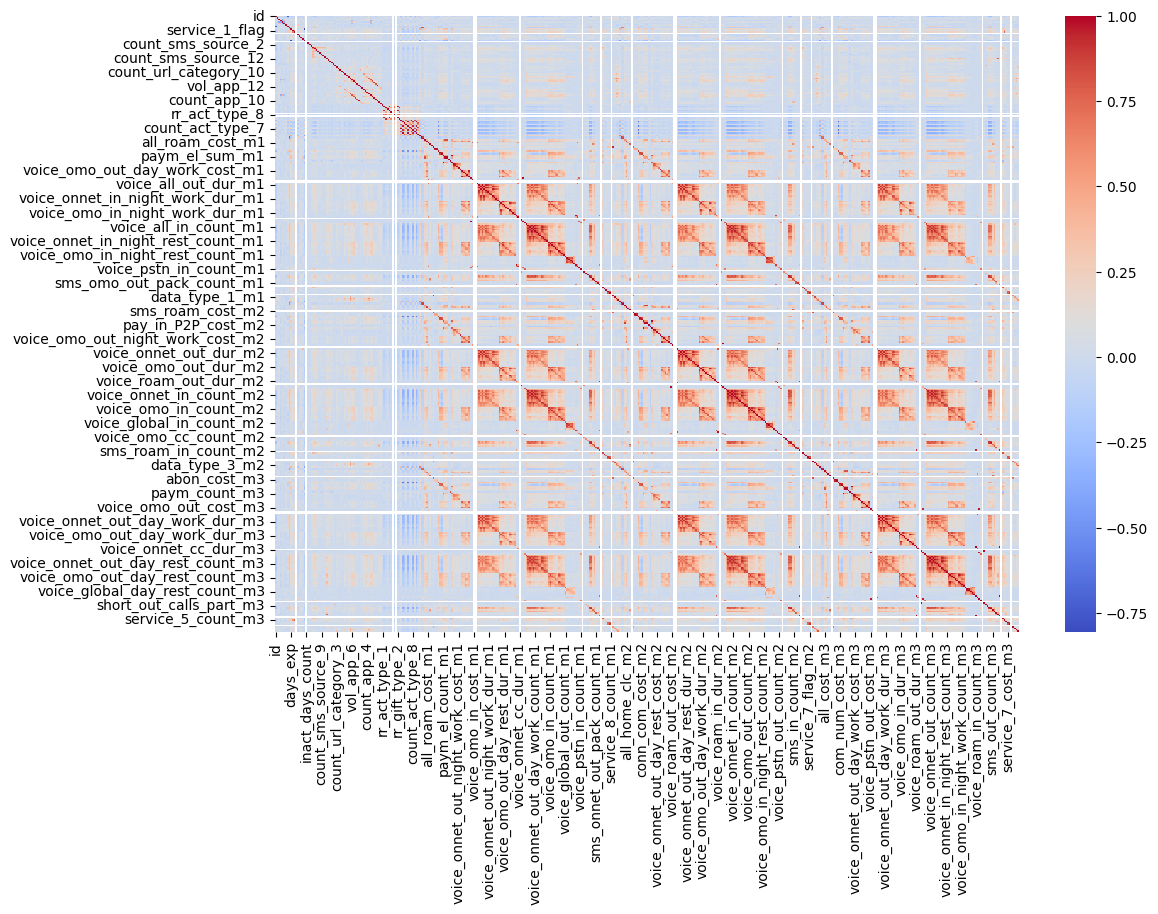

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()


In [ ]:
corr['target'].sort_values(ascending=False)


,target
target,1.000000
content_count_m1,0.203762
service_7_cost_m3,0.186424
content_count_m3,0.185748
content_count_m2,0.181527
...,...
voice_pstn_in_cost_m3,NaN
voice_onnet_cc_dur_m3,NaN
voice_onnet_cc_count_m3,NaN
sms_roam_in_count_m3,NaN


In [ ]:
corr = df.corr(numeric_only=True)

target_corr = corr['target'].drop('target')
top_corr = target_corr.abs().sort_values(ascending=False).head(20)

top_corr

,target
content_count_m1,0.203762
service_7_cost_m3,0.186424
content_count_m3,0.185748
content_count_m2,0.181527
service_7_flag_m3,0.150712
service_7_cost_m2,0.147121
service_7_flag_m2,0.140429
LT,0.132198
income_brnd_cont_m1,0.130619
service_7_cost_m1,0.126618


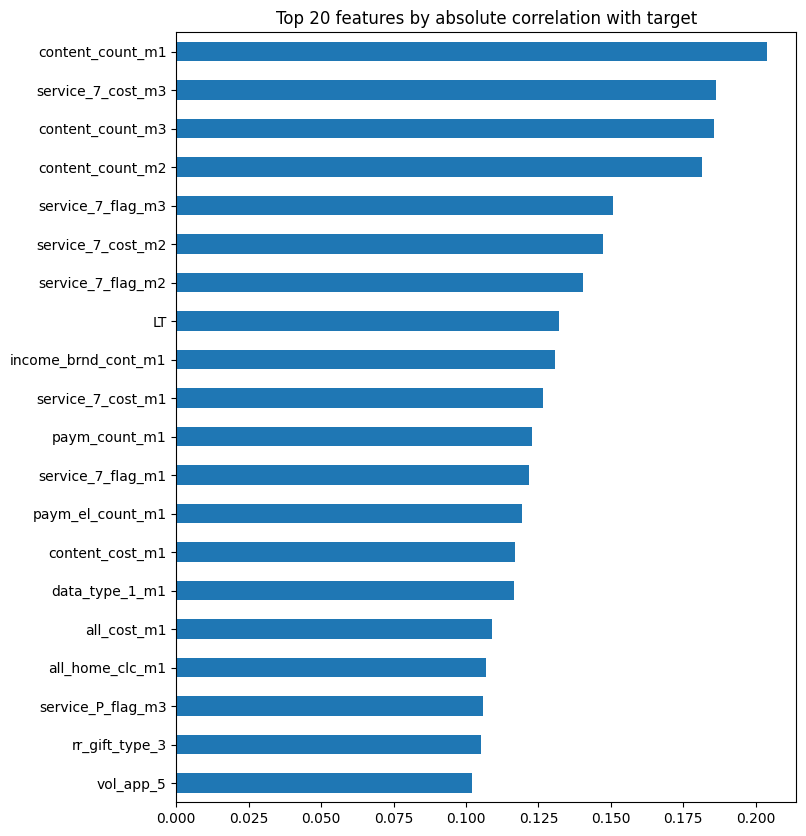

In [ ]:
plt.figure(figsize=(8,10))
top_corr.sort_values().plot(kind='barh')
plt.title("Top 20 features by absolute correlation with target")
plt.show()

У результаті кореляційного аналізу було визначено ознаки, які мають найбільший зв’язок із цільовою змінною target. Найбільш пов’язаними з таргетом є: content_count_m1 (0.20), service_7_cost_m3 (0.19), content_count_m3 (0.19), content_count_m2 (0.18), service_7_flag_m3 (0.15), а також інші змінні, пов’язані з витратами та використанням сервісів.

Значення коефіцієнтів кореляції знаходяться в межах 0.10–0.20, що свідчить про слабкий або ближче до помірного лінійний зв’язок. Жодна окрема ознака не має сильної (>0.3) залежності з таргетом.

Водночас видно, що найбільший вплив мають змінні, пов’язані з активністю користувача (content usage), витратами на сервіси та оплатами, що логічно з бізнес-точки зору — поведінкові характеристики клієнта впливають на його ймовірність належати до позитивного класу.

Оскільки кореляції не є високими, можна зробити висновок, що задача має складну багатофакторну природу. Для досягнення кращої якості прогнозу доцільно використовувати нелінійні моделі (Random Forest, Gradient Boosting, XGBoost), які здатні враховувати взаємодії між ознаками.

### Аналіз цільової змінної

In [ ]:
df['target'].value_counts()

,count
target,
0,1337
1,99


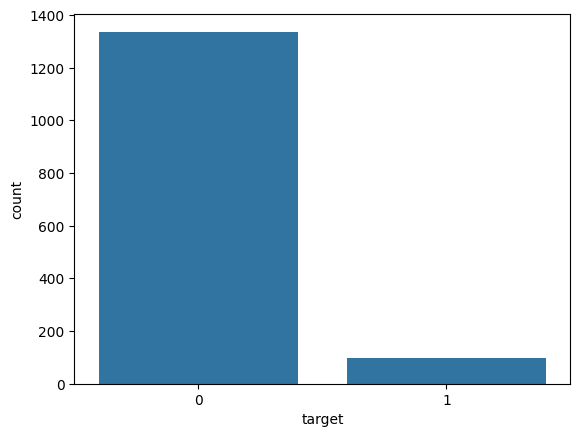

In [ ]:
sns.countplot(x='target', data=df)
plt.show()

### Зведені таблиці (Pivot Table)

In [ ]:
df.groupby('target').mean(numeric_only=True)

,id,device_type,manufacturer_category,os_category,sim_count,tp_flag,LT,block_flag,days_exp,service_1_flag,...,content_count_m3,service_5_count_m3,service_6_count_m3,service_7_cost_m3,service_7_flag_m3,service_8_count_m3,income_brnd_cont_m3,data_type_1_m3,data_type_2_m3,data_type_3_m3
target,,,,,,,,,,,,,,,,,,,,,
0,1.017854e+10,6.551982,896.584892,7.640239,1.623785,0.088257,0.822614,0.026178,317.881825,0.447270,...,47.003740,25.576664,0.050860,0.182670,0.039641,0.0,2.093780,227.603940,1655.832924,243.950061
1,1.473830e+10,6.666667,911.515152,5.595960,1.575758,0.050505,0.756833,0.010101,323.161616,0.353535,...,75.848485,19.212121,0.050505,1.743027,0.242424,0.0,4.372137,624.077312,1036.893879,272.564153


In [ ]:
pd.pivot_table(df,
               values='sim_count',
               index='target',
               aggfunc='mean')

,sim_count
target,
0,1.623785
1,1.575758


In [ ]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop(columns=['target'])
y = df['target']

mi = mutual_info_classif(X, y, random_state=42)

mi_series = pd.Series(mi, index=X.columns)
top_mi = mi_series.sort_values(ascending=False).head(20)

top_mi

,0
LT,0.023896
id,0.020480
service_P_flag_m3,0.016974
content_count_m1,0.016212
voice_all_out_dur_m3,0.016110
content_cost_m3,0.016043
sms_in_count_m3,0.016038
paym_count_m2,0.015534
voice_onnet_cc_count_m1,0.014516
voice_all_out_dur_m2,0.014435


У результаті оцінки важливості ознак за допомогою метрики Mutual Information (MI) було визначено, які змінні несуть найбільше інформації про цільову змінну target.

Найбільш інформативними виявилися ознаки вище.

Значення MI для цих змінних є невисокими (0.012–0.024), що свідчить про слабку, проте наявну залежність із таргетом. Це узгоджується з результатами кореляційного аналізу, де максимальні значення коефіцієнтів також були нижчими за 0.3.

Водночас MI дозволяє виявити додаткові важливі змінні, які лінійно не проявляють сильного зв’язку з target, але можуть бути корисні для прогнозних моделей. Наприклад, змінні voice_all_out_dur_m3, voice_omo_out_day_work_dur_m3, voice_omo_out_day_rest_dur_m2 та інші пов’язані з використанням голосових послуг, що не були серед топ-кореляційних.

Отже, завдяки MI видно, що задача має багатофакторну та частково нелінійну природу, і для досягнення кращої якості прогнозу доцільно застосовувати нелінійні моделі, такі як Random Forest, Gradient Boosting або XGBoost, які враховують взаємодії між ознаками.

In [ ]:
top_features = ['content_count_m1', 'service_7_cost_m3', 'content_count_m3', 'paym_el_count_m1', 'voice_all_out_dur_m3']

df.groupby('target')[top_features].mean()

df.groupby('target')[top_features].agg(['mean','median','std'])

content_count_m1                   service_7_cost_m3                   \
                   mean median        std              mean median       std   
target                                                                         
0             47.673897   40.0  37.983587          0.182670    0.0  1.462481   
1             81.272727   63.0  69.591640          1.743027    0.0  5.868836   

       content_count_m3                   paym_el_count_m1                   \
                   mean median        std             mean median       std   
target                                                                        
0             47.003740   41.0  36.184811         1.193717    1.0  1.580388   
1             75.848485   54.0  63.632292         2.000000    1.0  2.878492   

       voice_all_out_dur_m3                         
                       mean   median           std  
target                                              
0              20402.602842  12960.0  24365.950065  
1              22822.424242  10620.0  34103.365717

У результаті аналізу середніх значень ознак по класах (target = 0 та target = 1) видно, що поведінка класів значно відрізняється:

content_count_m1: у позитивного класу (target=1) середнє значення ~81, тоді як у негативного класу ~48. Це свідчить, що користувачі позитивного класу активніше використовують контент.

service_7_cost_m3: середнє у позитивного класу ~1.74, у негативного ~0.18, тобто витрати на сервіс у позитивного класу значно вищі.

content_count_m3: позитивний клас має ~76, негативний ~47, що підтверджує більшу активність у споживанні контенту.

paym_el_count_m1: середнє ~2 у позитивного класу та ~1 у негативного, тобто позитивний клас робить більше електронних платежів.

voice_all_out_dur_m3: середнє ~22 822 у позитивного класу та ~20 403 у негативного, що показує трохи більший обсяг голосових викликів.

Як висновок позитивний клас характеризується вищою активністю та витратами, а негативний — нижчими показниками. Різниця між класами достатньо наочна, що підтверджує, що ці ознаки є прогностично важливими для моделі.

# **Data Preprocessing**

### Об'єднання колонок (стовпців)

In [ ]:
import pandas as pd
import re

def aggregate_and_keep(df):
    df_new = df.copy()
    pattern = re.compile(r"(.+)_m([123])$")
    groups = {}

    # Збираємо колонки *_m1, *_m2, *_m3
    for col in df.columns:
        match = pattern.match(col)
        if match:
            base_name = match.group(1)
            month = match.group(2)
            if base_name not in groups:
                groups[base_name] = {}
            groups[base_name][month] = col

    # Створюємо нові агреговані колонки
    new_cols = {}
    for base, months in groups.items():
        if all(m in months for m in ["1", "2", "3"]):
            m1 = df[months["1"]]
            m2 = df[months["2"]]
            m3 = df[months["3"]]

            new_cols[f"{base}_sum3"] = m1 + m2 + m3
            new_cols[f"{base}_avg3"] = (m1 + m2 + m3) / 3
            new_cols[f"{base}_std3"] = pd.concat([m1, m2, m3], axis=1).std(axis=1)
            new_cols[f"{base}_trend"] = m1 - m3


    df_new = pd.concat([df_new, pd.DataFrame(new_cols)], axis=1)

    # Видаляємо старі *_m1/_m2/_m3
    df_new = df_new.drop(columns=[col for col in df_new.columns if pattern.match(col)])

    print("Агреговані колонки:")
    for col in new_cols.keys():
        print(col)

    return df_new

df_ready = aggregate_and_keep(df)

Агреговані колонки:
service_P_flag_sum3
service_P_flag_avg3
service_P_flag_std3
service_P_flag_trend
block_all_dur_sum3
block_all_dur_avg3
block_all_dur_std3
block_all_dur_trend
block_count_sum3
block_count_avg3
block_count_std3
block_count_trend
all_cost_sum3
all_cost_avg3
all_cost_std3
all_cost_trend
all_home_clc_sum3
all_home_clc_avg3
all_home_clc_std3
all_home_clc_trend
all_roam_cost_sum3
all_roam_cost_avg3
all_roam_cost_std3
all_roam_cost_trend
sms_cost_sum3
sms_cost_avg3
sms_cost_std3
sms_cost_trend
sms_roam_cost_sum3
sms_roam_cost_avg3
sms_roam_cost_std3
sms_roam_cost_trend
content_cost_sum3
content_cost_avg3
content_cost_std3
content_cost_trend
abon_cost_sum3
abon_cost_avg3
abon_cost_std3
abon_cost_trend
abon_part_sum3
abon_part_avg3
abon_part_std3
abon_part_trend
act_days_count_sum3
act_days_count_avg3
act_days_count_std3
act_days_count_trend
com_num_cost_sum3
com_num_cost_avg3
com_num_cost_std3
com_num_cost_trend
conn_com_cost_sum3
conn_com_cost_avg3
conn_com_cost_std3
conn_c

In [ ]:
# Виводимо всі колонки (агреговані + неагреговані)
print("Всі колонки після агрегації:")
for i, col in enumerate(df_ready.columns, 1):
    print(i, col)

Всі колонки після агрегації:
1 id
2 target
3 device_type
4 manufacturer_category
5 os_category
6 sim_count
7 tp_flag
8 LT
9 block_flag
10 days_exp
11 service_1_flag
12 service_1_count
13 service_2_flag
14 service_3_flag
15 is_obl_center
16 is_my_vf
17 balance_sum
18 paym_last_days
19 inact_days_count
20 count_sms_source_1
21 count_sms_source_2
22 count_sms_source_3
23 count_sms_source_4
24 count_sms_source_5
25 count_sms_source_6
26 count_sms_source_7
27 count_sms_source_8
28 count_sms_source_9
29 count_sms_source_10
30 count_sms_source_11
31 count_sms_source_12
32 count_sms_source_13
33 count_sms_source_14
34 count_sms_source_15
35 count_sms_source_16
36 count_url_category_2
37 count_url_category_3
38 count_url_category_4
39 count_url_category_7
40 count_url_category_9
41 count_url_category_10
42 vol_app_1
43 vol_app_2
44 vol_app_4
45 vol_app_5
46 vol_app_6
47 vol_app_7
48 vol_app_8
49 vol_app_9
50 vol_app_10
51 vol_app_12
52 vol_app_15
53 count_app_1
54 count_app_2
55 count_app_4
56 

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

X = df.drop(columns=['target', 'id'])
y = df['target'].astype(int)

# Розділяємо на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Масштабування числових ознак
numeric_cols = X.select_dtypes(include=['float64','int64']).columns
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Список для збереження результатів
results = []

# === Logistic Regression ===
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_params = {'C':[0.01,0.1,1,10], 'penalty':['l2']}
lr_grid = GridSearchCV(lr, lr_params, scoring='roc_auc', cv=3)
lr_grid.fit(X_train, y_train)
y_pred_lr = lr_grid.predict(X_test)
y_prob_lr = lr_grid.predict_proba(X_test)[:,1]

results.append({
    'Model': 'Logistic Regression',
    'Best params': lr_grid.best_params_,
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_lr),3),
    'Accuracy': round((y_test==y_pred_lr).mean(),3),
    'F1 (class 1)': round(classification_report(y_test, y_pred_lr, output_dict=True)['1']['f1-score'],3),
    'Precision (class 1)': round(classification_report(y_test, y_pred_lr, output_dict=True)['1']['precision'],3),
    'Recall (class 1)': round(classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall'],3)
})

# === Random Forest ===
rf = RandomForestClassifier(random_state=42)
rf_params = {'n_estimators':[100,200], 'max_depth':[5,10,20]}
rf_grid = GridSearchCV(rf, rf_params, scoring='roc_auc', cv=3)
rf_grid.fit(X_train, y_train)
y_pred_rf = rf_grid.predict(X_test)
y_prob_rf = rf_grid.predict_proba(X_test)[:,1]

results.append({
    'Model': 'Random Forest',
    'Best params': rf_grid.best_params_,
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_rf),3),
    'Accuracy': round((y_test==y_pred_rf).mean(),3),
    'F1 (class 1)': round(classification_report(y_test, y_pred_rf, output_dict=True)['1']['f1-score'],3),
    'Precision (class 1)': round(classification_report(y_test, y_pred_rf, output_dict=True)['1']['precision'],3),
    'Recall (class 1)': round(classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall'],3)
})

# === XGBoost ===
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_params = {'n_estimators':[100,200], 'max_depth':[3,5,7], 'learning_rate':[0.01,0.1]}
xgb_grid = GridSearchCV(xgb, xgb_params, scoring='roc_auc', cv=3)
xgb_grid.fit(X_train, y_train)
y_pred_xgb = xgb_grid.predict(X_test)
y_prob_xgb = xgb_grid.predict_proba(X_test)[:,1]

results.append({
    'Model': 'XGBoost',
    'Best params': xgb_grid.best_params_,
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_xgb),3),
    'Accuracy': round((y_test==y_pred_xgb).mean(),3),
    'F1 (class 1)': round(classification_report(y_test, y_pred_xgb, output_dict=True)['1']['f1-score'],3),
    'Precision (class 1)': round(classification_report(y_test, y_pred_xgb, output_dict=True)['1']['precision'],3),
    'Recall (class 1)': round(classification_report(y_test, y_pred_xgb, output_dict=True)['1']['recall'],3)
})

# Перетворюємо результати на DataFrame і виводимо
results_df = pd.DataFrame(results)
print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

                 Model                                        Best params  \
0  Logistic Regression                       {'C': 0.01, 'penalty': 'l2'}   
1        Random Forest             {'max_depth': 10, 'n_estimators': 200}   
2              XGBoost  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...   

   ROC-AUC  Accuracy  F1 (class 1)  Precision (class 1)  Recall (class 1)  
0    0.744     0.931         0.091                  0.5              0.05  
1    0.814     0.931         0.000                  0.0              0.00  
2    0.797     0.934         0.095                  1.0              0.05  


Усі моделі показують високу точність через сильний дисбаланс класів, проте здатність виявляти рідкісний клас (class 1) дуже низька. Найкращий показник ROC-AUC демонструє Random Forest (0.814), що свідчить про її найкращу здатність розрізняти класи. Logistic Regression і XGBoost теж показують прийнятні ROC-AUC, але всі моделі потребують додаткової роботи з балансом класів для покращення F1 та recall рідкісного класу.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:39:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:39:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:39:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:39:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

                 Model  CV mean ROC-AUC  CV std  Train ROC-AUC  Test ROC-AUC
0  Logistic Regression            0.722   0.033          0.908         0.744
1        Random Forest            0.720   0.068          1.000         0.814
2              XGBoost            0.779   0.038          1.000         0.797


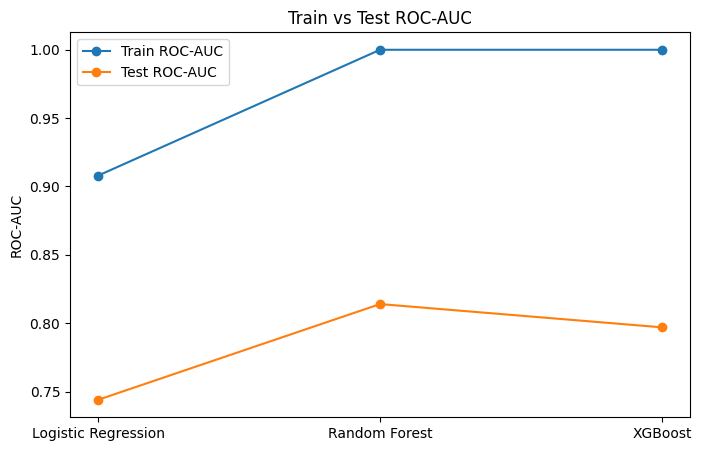

In [ ]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'Random Forest': rf_grid.best_estimator_,
    'XGBoost': xgb_grid.best_estimator_
}

cv_results = []

for name, model in models.items():
    # Cross-validation ROC-AUC на train
    cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')

    # Оцінка на train та test
    model.fit(X_train, y_train)
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:,1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

    cv_results.append({
        'Model': name,
        'CV mean ROC-AUC': round(cv_score.mean(),3),
        'CV std': round(cv_score.std(),3),
        'Train ROC-AUC': round(train_auc,3),
        'Test ROC-AUC': round(test_auc,3)
    })

cv_df = pd.DataFrame(cv_results)
print(cv_df)

# Простий графік для аналізу over/underfitting
plt.figure(figsize=(8,5))
plt.plot(cv_df['Model'], cv_df['Train ROC-AUC'], marker='o', label='Train ROC-AUC')
plt.plot(cv_df['Model'], cv_df['Test ROC-AUC'], marker='o', label='Test ROC-AUC')
plt.title('Train vs Test ROC-AUC')
plt.ylabel('ROC-AUC')
plt.legend()
plt.show()

На основі результатів можна зробити такі висновки: Logistic Regression показує трохи кращу стабільність і незначний overfitting, оскільки на тренувальних даних ROC-AUC вища, ніж на тестових, але крос-валідація показує стабільні значення. Random Forest та XGBoost демонструють явний overfitting: на тренувальних даних вони досягають ROC-AUC 1.0, тоді як на тестових значно нижчі результати. Для цих моделей можна застосувати регуляризацію або обмежити глибину дерев, щоб покращити узагальнювальну здатність.

## Error Analysis

Logistic Regression Confusion Matrix:
 [[267   1]
 [ 19   1]]
Random Forest Confusion Matrix:
 [[268   0]
 [ 20   0]]
XGBoost Confusion Matrix:
 [[268   0]
 [ 19   1]]


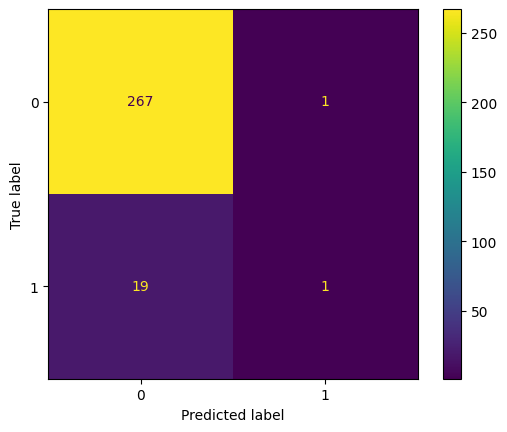

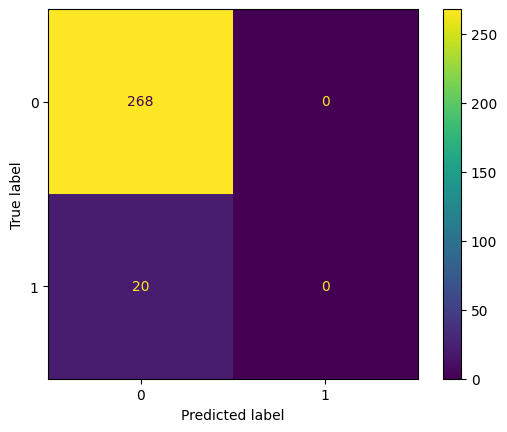

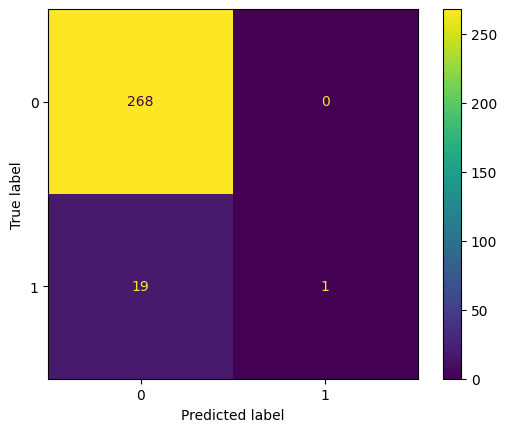

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=[0,1])
disp_lr.plot()
print("Logistic Regression Confusion Matrix:\n", cm_lr)

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=[0,1])
disp_rf.plot()
print("Random Forest Confusion Matrix:\n", cm_rf)

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(cm_xgb, display_labels=[0,1])
disp_xgb.plot()
print("XGBoost Confusion Matrix:\n", cm_xgb)

Всі моделі добре класифікують більшість (клас 0), але погано визначають рідкісний клас 1.

Основна помилка — false negatives (клас 1 передбачено як 0).

## Limitations & Next Steps

1. Обмеження моделі та даних

Дисбаланс класів: Найбільше обмеження у цьому проєкті — значний дисбаланс між класами. Переважна більшість абонентів належить до класу 0, тоді як рідкісний клас 1 майже не представлений. Це призвело до того, що більшість моделей (особливо Random Forest) практично не розпізнають рідкісний клас, з високим рівнем false negatives.

Малий розмір вибірки для рідкісного класу: Через обмежену кількість прикладів класу 1, моделі не отримали достатньо інформації для коректного навчання на цьому класі.

Вибір ознак: На даному етапі виконано базову інженерію ознак (Feature Engineering) та простий відбір ознак. Можливе існування додаткових корисних ознак, які могли б підвищити продуктивність моделей.

Моделі без спеціальних налаштувань для дисбалансу: Використані моделі (Logistic Regression, Random Forest, XGBoost) працюють з дефолтними або базовими параметрами, що не враховують дисбаланс класів, окрім стандартного ROC-AUC для оцінки.

2. Обмеження оцінки

Метрика: Для оцінки ефективності обрано переважно ROC-AUC, що добре відображає здатність моделі відрізняти класи, але менш інформативна щодо точності передбачень рідкісного класу. Метрики F1, Precision, Recall показують, що моделі практично не розпізнають рідкісний клас, що може бути критично для практичного застосування.

Cross-validation: Використано лише базову крос-валідацію для оцінки стабільності моделей, без додаткових технік, як Nested CV, що обмежує надійність оцінки підбору гіперпараметрів.

3. Пропозиції для покращення (Next Steps)

Балансування класів: Застосувати методи oversampling (SMOTE, ADASYN), undersampling або використання class_weight для підвищення чутливості моделей до рідкісного класу.

Розширена інженерія ознак: Створення нових ознак на основі взаємодій існуючих, часових показників або агрегованих метрик може покращити здатність моделей відокремлювати класи.

Вибір моделей та оптимізація: Спробувати додаткові алгоритми, такі як LightGBM, CatBoost, або ансамблі моделей для підвищення точності на рідкісному класі.

Регуляризація та tuning: Виконати більш детальну оптимізацію гіперпараметрів, включаючи регуляризацію та ранню зупинку для бустингових моделей, щоб уникнути overfitting на класі 0.

Більш глибокий аналіз помилок: Провести сегментацію абонентів, на яких моделі помиляються, для виявлення закономірностей і слабких місць моделей.

Метрики для дисбалансу: Додати специфічні метрики для рідкісного класу, як balanced accuracy, Matthews correlation coefficient (MCC), або Precision-Recall AUC, що краще оцінюють ефективність на нерівномірних класах.

Збір додаткових даних: Якщо можливо, збільшення кількості прикладів рідкісного класу значно підвищить здатність моделей до навчання та стабільність прогнозів.